# INSTRUCTOR SOLUTION: Deep Reinforcement Learning
## AIAT 123 - Reinforcement Learning

**⚠️ INSTRUCTOR USE ONLY**

This solution demonstrates the complete implementation.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import torch
import torch.nn as nn

print("✅ Setup complete!")

✅ Setup complete!


## Student Support Pack

Use this section to study the solution actively, not passively.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim),
        )

    def forward(self, x):
        return self.net(x)


q_net = QNetwork()
print(q_net)

q_pred = torch.tensor([1.2, 0.8, 1.5])
rewards = torch.tensor([1.0, 0.0, 1.0])
q_next = torch.tensor([1.3, 0.4, 1.8])
done = torch.tensor([0.0, 1.0, 0.0])
gamma = 0.99

q_target = rewards + gamma * q_next * (1 - done)
loss = nn.MSELoss()(q_pred, q_target)

print("\nTarget values:", q_target)
print("Loss:", round(loss.item(), 4))

print("\nInstructor note:")
print("A strong student answer should explain why target networks and replay buffers")
print("improve stability, not only reproduce the equations.")

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

Target values: tensor([2.2870, 0.0000, 2.7820])
Loss: 1.155

Instructor note:
A strong student answer should explain why target networks and replay buffers
improve stability, not only reproduce the equations.


### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


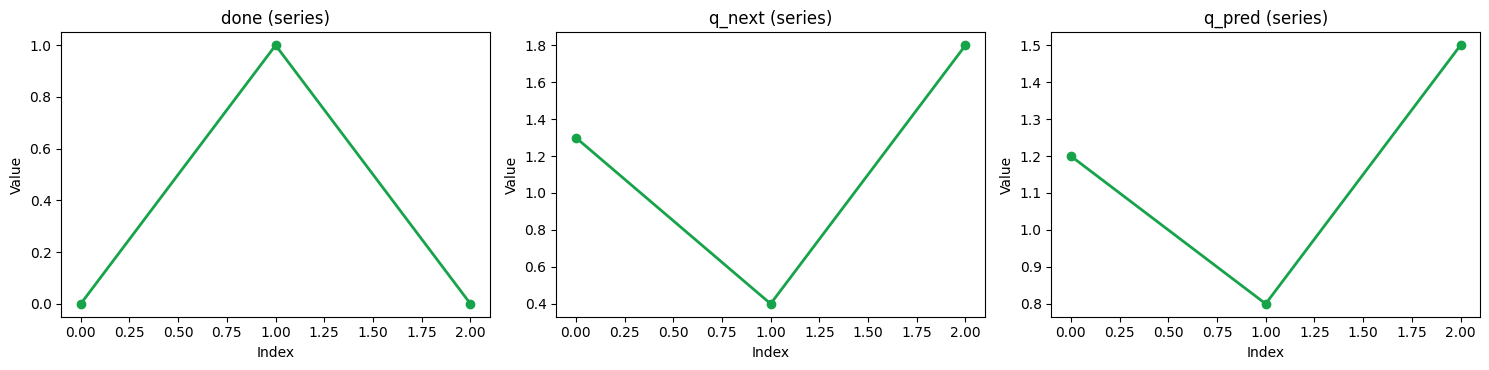

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
